In [ ]:
#Installing required libraries

#!pip install pandas numpy matplotlib seaborn nltk textblob scikit-learn

   ---------------------------------------- 0.0/624.3 kB ? eta -:--:--
   --------------------------------- ------ 524.3/624.3 kB 3.4 MB/s eta 0:00:01
   ---------------------------------------- 624.3/624.3 kB 3.3 MB/s eta 0:00:00


In [ ]:
# Importing libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix

In [2]:
# Loading the model dataset
df = pd.read_csv("D:/Behavioural_SaaS_chun_analysis/data/processed/churn_model_dataset.csv")

df.head()

,account_id,plan_tier,seats,total_usage,total_errors,features_used,ticket_count,avg_satisfaction_score,churn_flag
0,A-00bed1,Basic,28,514,27,32,4,4.0,0
1,A-00cac8,Enterprise,8,602,31,30,2,0.0,0
2,A-0158bb,Basic,5,364,22,19,1,3.0,0
3,A-016043,Basic,4,490,21,26,3,4.0,0
4,A-019782,Enterprise,11,562,30,28,2,3.0,0


**Basic Exploration:**

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 9 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   account_id              500 non-null    object 
 1   plan_tier               500 non-null    object 
 2   seats                   500 non-null    int64  
 3   total_usage             500 non-null    int64  
 4   total_errors            500 non-null    int64  
 5   features_used           500 non-null    int64  
 6   ticket_count            500 non-null    int64  
 7   avg_satisfaction_score  500 non-null    float64
 8   churn_flag              500 non-null    int64  
dtypes: float64(1), int64(6), object(2)
memory usage: 35.3+ KB


In [4]:
df['churn_flag'].value_counts()

churn_flag
0    390
1    110
Name: count, dtype: int64

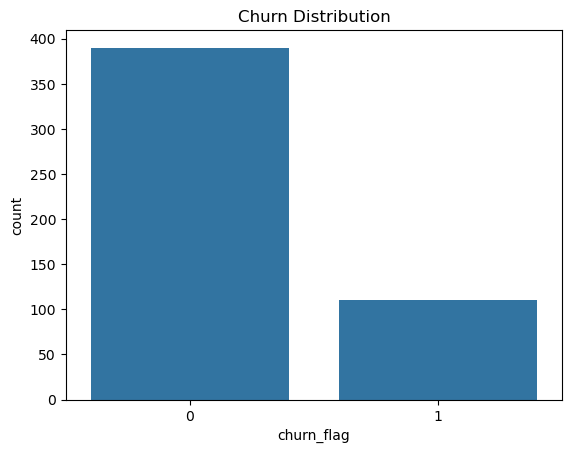

In [5]:
#Checking churn distribution

sns.countplot(x='churn_flag', data=df)
plt.title("Churn Distribution")
plt.show()

***Machine learning models cannot read text.***

**So converting:**

Basic → 0
Pro → 1
Enterprise → 2

In [6]:
df['plan_tier'] = df['plan_tier'].map({
    'Basic':0,
    'Pro':1,
    'Enterprise':2
})

In [7]:
df.head()

,account_id,plan_tier,seats,total_usage,total_errors,features_used,ticket_count,avg_satisfaction_score,churn_flag
0,A-00bed1,0,28,514,27,32,4,4.0,0
1,A-00cac8,2,8,602,31,30,2,0.0,0
2,A-0158bb,0,5,364,22,19,1,3.0,0
3,A-016043,0,4,490,21,26,3,4.0,0
4,A-019782,2,11,562,30,28,2,3.0,0


**Defining Features and Target**

In [8]:
#Features
X = df[['plan_tier',
        'seats',
        'total_usage',
        'total_errors',
        'features_used',
        'ticket_count',
        'avg_satisfaction_score']]
#Target
y = df['churn_flag']

In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size= 0.2,
    random_state= 42
)

In [20]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

**Training Logestic Regression Model**

In [21]:
model = LogisticRegression()

model.fit(X_train, y_train)

LogisticRegression()

In [22]:
# Model Predictions

y_pred = model.predict(X_test)

In [23]:
# Model evaluation

confusion_matrix(y_test, y_pred)

print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.78      1.00      0.88        78
           1       0.00      0.00      0.00        22

    accuracy                           0.78       100
   macro avg       0.39      0.50      0.44       100
weighted avg       0.61      0.78      0.68       100



c:\Users\harin\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\harin\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\harin\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [24]:
# Feature Importance

importance = pd.DataFrame({
    'feature': X.columns,
    'importance': model.coef_[0]
})

importance.sort_values(by='importance', ascending=False)

,feature,importance
4,features_used,0.299564
6,avg_satisfaction_score,0.160777
2,total_usage,0.097054
0,plan_tier,-0.032395
5,ticket_count,-0.078728
1,seats,-0.120776
3,total_errors,-0.237223


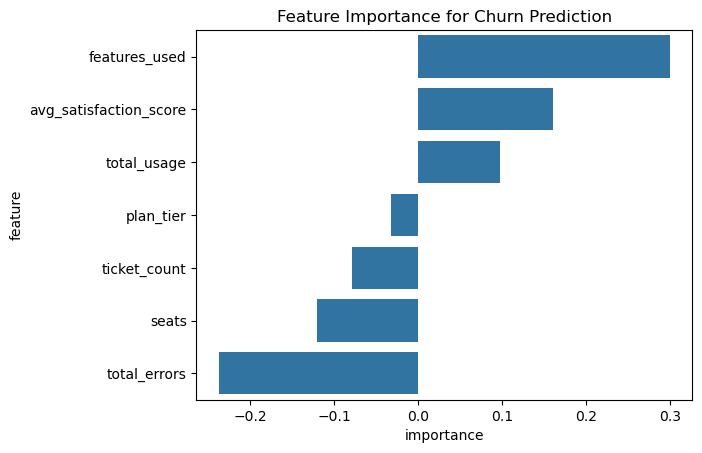

In [25]:
sns.barplot(
    data= importance.sort_values(by='importance', ascending=False),
    x='importance',
    y='feature'
)

plt.title("Feature Importance for Churn Prediction")
plt.show()

The model predicted all customers as active. It failed to identify churned customers due to **imbalanced** dataset.

In [26]:
# improvement

model = LogisticRegression(class_weight='balanced', max_iter= 2000)

In [27]:
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.81      0.54      0.65        78
           1       0.25      0.55      0.34        22

    accuracy                           0.54       100
   macro avg       0.53      0.54      0.49       100
weighted avg       0.69      0.54      0.58       100



The baseline logistic regression model initially achieved 78% accuracy but failed to identify churned customers due to class imbalance. After applying class weighting to address imbalance, the model successfully detected 55% of churn cases, demonstrating the importance of balancing techniques in churn prediction problems.